# Thêm thư viện

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Đọc dữ liệu từ file
## Mô tả tập dữ liệu
- Source: UCI - ADULT
- Download link: https://archive.ics.uci.edu/dataset/2/adult
- Số record: 32560
- Số thuộc tính: 15
- Mô tả: Các bản ghi được trích xuất từ cơ sở dữ liệu Điều tra dân số năm 1994.
- Potential use cases: Dự đoán thu nhập của một cá nhân trên hay dưới 50000 đô la/năm dựa trên các đặc điểm cá nhân của người đó. Phân tích mối quan hệ giữa thu nhập với các yếu tố như trình độ học vấn, loại hình công việc, thời gian làm việc, độ tuổi. Phân tích sự chênh lệch thu nhập giữa các nhóm dân cư, hỗ trợ ra quyết định trong kinh tế, xã hội.

In [30]:
train_data = pd.read_csv("D:/Documents/Temp/adult/adult.csv", skipinitialspace=True, na_values="?")

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# a) Handling Missing Data
## Kiểm tra dữ liệu thiếu

,Total,Percent
age,0,0.000000
workclass,1836,0.056386
fnlwgt,0,0.000000
education,0,0.000000
education-num,0,0.000000
marital-status,0,0.000000
occupation,1843,0.056601
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


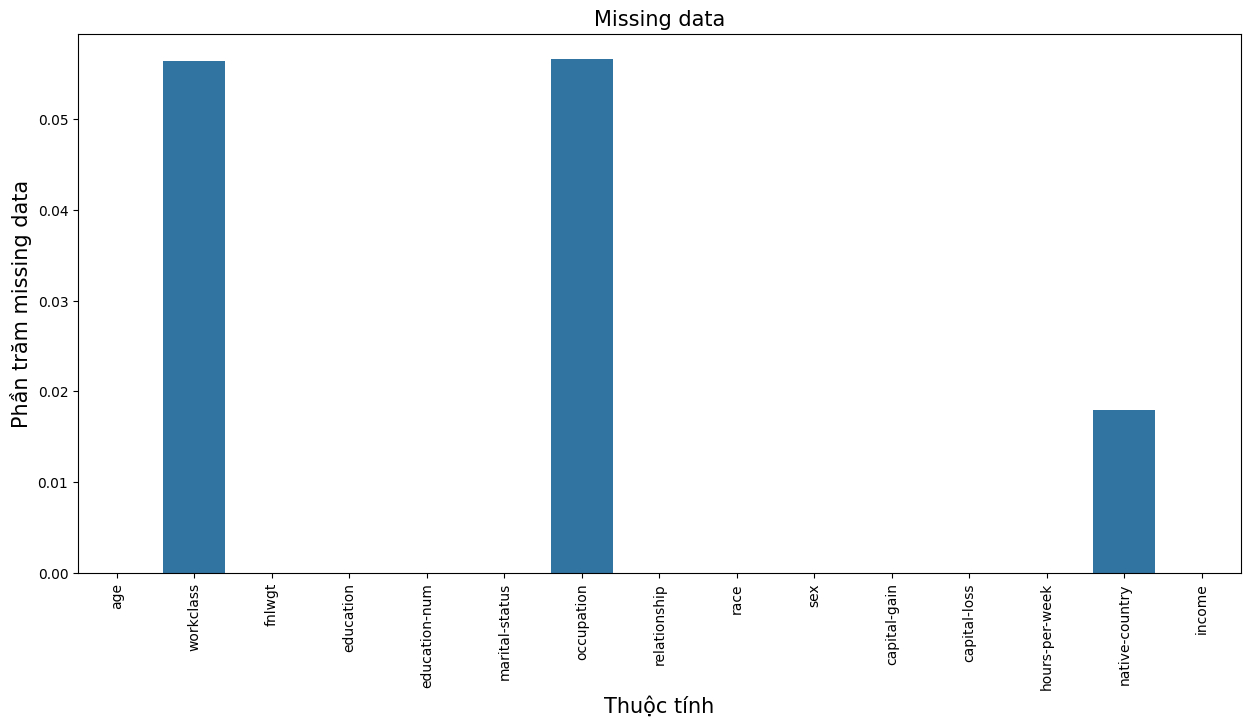

In [31]:
total = train_data.isnull().sum()

# Tính phần trăm missing data
percent = (train_data.isnull().sum()/train_data.isnull().count())

# Tạo DataFrame hiển thị tổng số và phần trăm missing data
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
f, ax = plt.subplots(figsize=(15, 7))

# Vẽ biểu đồ
plt.xticks(rotation=90)
sns.barplot(x=missing_data.index, y=missing_data['Percent'])
plt.xlabel('Thuộc tính', fontsize=15)
plt.ylabel('Phần trăm missing data', fontsize=15)
plt.title('Missing data', fontsize=15)

missing_data.head(15)



## So sánh với các thuộc tính khác

In [32]:
# Phân tích mối quan hệ giữa missing data và biến mục tiêu 'income'
table_workclass_income = pd.crosstab(train_data["workclass"].isnull(), train_data["income"], normalize='index')
table_occupation_income = pd.crosstab(train_data["occupation"].isnull(), train_data["income"], normalize='index')
table_native_country_income = pd.crosstab(train_data["native-country"].isnull(), train_data["income"], normalize='index')

table_workclass_income, table_occupation_income, table_native_country_income

(income        <=50K      >50K
 workclass                    
 False      0.751017  0.248983
 True       0.895969  0.104031,
 income         <=50K      >50K
 occupation                    
 False       0.750960  0.249040
 True        0.896365  0.103635,
 income             <=50K      >50K
 native-country                    
 False           0.759366  0.240634
 True            0.749571  0.250429)

### Nhận xét
- workclass: nhóm bị thiếu workclass có tỷ lệ thu nhập >50K nhỏ hơn đáng kể so với nhóm không thiếu (0.104031 và 0.248983), điều này cho thấy missing không xảy ra ngẫu nhiên.
- occupation: tương tự như workclass, nhóm bị thiếu occupation có tỷ lệ thu nhập >50K nhỏ hơn đáng kể so với nhóm không thiếu (0.104031 và 0.248983).
- native-country: không có sự khác biệt nhiều ở nhóm bị thiếu và không bị thiếu.

In [33]:
# Phân tích mối quan hệ giữa missing data và biến 'sex'
table_workclass_sex = pd.crosstab(train_data["workclass"].isnull(), train_data["sex"], normalize='index')
table_occupation_sex = pd.crosstab(train_data["occupation"].isnull(), train_data["sex"], normalize='index')
table_native_country_sex = pd.crosstab(train_data["native-country"].isnull(), train_data["sex"], normalize='index')

table_workclass_sex, table_occupation_sex, table_native_country_sex

(sex          Female      Male
 workclass                    
 False      0.323255  0.676745
 True       0.456972  0.543028,
 sex           Female      Male
 occupation                    
 False       0.323263  0.676737
 True        0.456321  0.543679,
 sex               Female      Male
 native-country                    
 False           0.331728  0.668272
 True            0.279588  0.720412)

### Nhận xét
Các quan sát bị thiếu ở các biến workclass, occupation và native-country có cơ cấu giới tính khác biệt so với nhóm dữ liệu đầy đủ. Đối với workclass và occupation, tỷ lệ nữ trong nhóm bị thiếu cao hơn đáng kể, trong khi với native-country, nhóm bị thiếu lại có tỷ lệ nam cao hơn. Điều này cho thấy dữ liệu bị thiếu không xuất hiện hoàn toàn ngẫu nhiên, mà có mối liên hệ với biến giới tính.

In [34]:
# Phân tích mối quan hệ giữa missing data và biến 'education'
table_workclass_education = pd.crosstab(train_data["workclass"].isnull(), train_data["education"], normalize='index')
table_occupation_education = pd.crosstab(train_data["occupation"].isnull(), train_data["education"], normalize='index')
table_native_country_education = pd.crosstab(train_data["native-country"].isnull(), train_data["education"], normalize='index')

table_workclass_education, table_occupation_education, table_native_country_education

(education      10th      11th      12th   1st-4th   5th-6th   7th-8th  \
 workclass                                                               
 False      0.027111  0.034402  0.012791  0.005077  0.009862  0.018682   
 True       0.054466  0.064270  0.021786  0.006536  0.016340  0.039216   
 
 education       9th  Assoc-acdm  Assoc-voc  Bachelors  Doctorate   HS-grad  \
 workclass                                                                    
 False      0.015069    0.033198   0.042994   0.168657   0.012954  0.324459   
 True       0.027778    0.025599   0.033224   0.094227   0.008170  0.289760   
 
 education   Masters  Preschool  Prof-school  Some-college  
 workclass                                                  
 False      0.054516   0.001497     0.018161      0.220570  
 True       0.026144   0.002723     0.009804      0.279956  ,
 education       10th      11th      12th   1st-4th   5th-6th   7th-8th  \
 occupation                                                     

### Nhận xét
Kết quả phân tích cho thấy có sự khác biệt khá đáng kể ở nhóm bị thiếu và nhóm đủ ở cả 3 thuộc tính thiếu. Điều này cho thấy xác suất dữ liệu bị thiếu có mối liên hệ với 'education'.

Qua cả ba so sánh ('income', 'sex', 'education'), có thể thấy dữ liệu bị thiếu có sự khác biệt trong cơ cấu khá đáng kể với nhóm dữ liệu đầy đủ, cơ chế missing không hoàn toàn là ngẫu nhiên, có thể thuộc dạng MAR. Theo như em tìm hiểu thì để xác định bộ dữ liệu có thuộc MNAR thì phải dựa vào quy tắc nghiệp vụ hoặc thông tin ngoài dữ liệu quan sát được, do đó không thể kết luận MNAR dựa trên phân tích dữ liệu hiện có.

### Điền dữ liệu
Do dữ liệu không có tính thời gian nên forward/backward fill không phù hợp. Vì cả ba thuộc tính thiếu đều thuộc loại dữ liệu categorical nên mean, median và K-NN không phù hợp, vì vậy mode imputation được áp dụng khá tốt cho các biến này. Ngoài ra, ta có thể encoding categorical trước rồi áp dụng K-NN imputation để so sánh, đánh giá. Nhưng nếu encoding được thì cả mean và median đều có thể áp dụng được, tuy nhiên, nếu dùng mean trong trường hợp này, giá trị có thể bị sai do tính toán ra số thập phân, đối với median, nếu chọn được trung vị thì cũng bất hợp lý do giá trị trung vị là do ta tự quy ước, áp đặt cấu trúc giả, dữ liệu bị bóp méo. Do đó, trong trường hợp này, chúng em sử dụng 2 imputation là mode và K-NN.
#### Mode imputation
Sử dụng SimpleImputer của thư viện Scikit-Learn với chiến lược "most_frequent" để điền dữ liệu còn thiếu.

In [35]:
# Điền missing data cho các thuộc tính thiếu bằng giá trị phổ biến nhất
cat_cols = ["workclass", "occupation", "native-country"]

# Sử dụng SimpleImputer để điền missing data
mode_imputer = SimpleImputer(strategy="most_frequent")
# Tạo bản sao của dữ liệu gốc để điền missing data
train_data_with_mode = train_data.copy()
train_data_with_mode[cat_cols] = mode_imputer.fit_transform(train_data[cat_cols])

# Kiểm tra lại missing data sau khi điền
train_data_with_mode[cat_cols].isnull().sum()

workclass         0
occupation        0
native-country    0
dtype: int64

In [36]:
# So sánh phân phối trước và sau khi điền missing data
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(f"\nBefore")
    print(train_data[col].value_counts(normalize=True).head(5))

    print(f"\nAfter")
    print(train_data_with_mode[col].value_counts(normalize=True).head(5))


Column: workclass

Before
workclass
Private             0.738682
Self-emp-not-inc    0.082701
Local-gov           0.068120
State-gov           0.042246
Self-emp-inc        0.036322
Name: proportion, dtype: float64

After
workclass
Private             0.753417
Self-emp-not-inc    0.078038
Local-gov           0.064279
State-gov           0.039864
Self-emp-inc        0.034274
Name: proportion, dtype: float64

Column: occupation

Before
occupation
Prof-specialty     0.134774
Craft-repair       0.133440
Exec-managerial    0.132365
Adm-clerical       0.122729
Sales              0.118823
Name: proportion, dtype: float64

After
occupation
Prof-specialty     0.183747
Craft-repair       0.125887
Exec-managerial    0.124873
Adm-clerical       0.115783
Sales              0.112097
Name: proportion, dtype: float64

Column: native-country

Before
native-country
United-States    0.912190
Mexico           0.020108
Philippines      0.006192
Germany          0.004284
Canada           0.003784
Name: prop

##### Nhận xét
Sau bước điền dữ liệu bằng mode imputation, ta có thể thấy số dữ liệu missing là 0 cho cả 3 thuộc tính thiếu và phân bố của các biến hầu như không đổi nhiều cho thấy giá trị bị thiếu tương đối nhỏ và việc điền bằng mode không làm biến dạng đáng kể. 
##### Ưu điểm:
- Phù hợp cho biến phân loại.
- Dễ dàng thực hiện và tính toán, hiệu quả khi tỉ lệ thiếu nhỏ.
##### Nhược điểm:
- Làm thay đổi tần suất các biến nếu tỉ lệ thiếu lớn.
- Làm giảm phương sai, giảm sự đa dạng của dữ liệu, các mô hình học máy khó học được mối quan hệ giữa các dữ liệu.

#### K-NN Imputation
Vì datasets khá lớn (32650 records), việc xác định K quá nhỏ (1-2) sẽ làm dữ liệu dễ nhiễu, dễ bị lệch, còn K quá lớn (10-20) sẽ tốn nhiều chi phí, dữ liệu sẽ mượt quá mức, gần giống với mean, mode. Vì vậy, em chọn K = 5 để dữ liệu sau khi điền không quá nhiễu cũng không quá phẳng.

In [37]:
non_encoded_train_data_with_KNN = train_data.copy()

# Chuyển đổi các biến categorical thành biến giả
encoded_train_data = pd.get_dummies(non_encoded_train_data_with_KNN, dummy_na=True)

# Sử dụng KNNImputer để điền missing data
train_data_with_KNN = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(encoded_train_data), columns=encoded_train_data.columns)

# Kiểm tra lại missing data sau khi điền bằng KNN
train_data_with_KNN.isnull().sum().sum()

np.int64(0)

In [38]:
# So sánh kích thước dữ liệu sau khi điền missing data bằng KNN
table = pd.DataFrame({
    "Gốc": [train_data.shape[0], train_data.shape[1]],
    "Mode Imputation": [train_data_with_mode.shape[0], train_data_with_mode.shape[1]],
    "KNN Imputation": [train_data_with_KNN.shape[0], train_data_with_KNN.shape[1]]
}, index=["Number of Rows", "Number of Columns"])   
table

,Gốc,Mode Imputation,KNN Imputation
Number of Rows,32561,32561,32561
Number of Columns,15,15,116


##### Nhận xét
Sau khi điền dữ liệu bằng KNN, có thể thấy số dữ liệu missing là 0, nhưng số chiều của KNN tăng mạnh (từ 15 tăng lên 116). Kết quả cho thấy KNN có thể xử lý missing data hiệu quả, tuy nhiên dữ liệu sau khi xử lý có số chiều lớn và khó diễn giải. Do đó, KNN imputation chỉ được chúng em sử dụng để so sánh, trong khi mode imputation được lựa chọn làm phương pháp chính.
##### Ưu điểm
- Dữ liệu được điền có cơ sở, không máy móc.
- Giữ được cấu trúc của dữ liệu.
##### Nhược điểm
- Tốn nhiều chi phí, KNN phải lưu toàn bộ dữ liệu huấn luyện và tính toán mỗi khi dự đoán, gây tiêu tốn tài nguyên và thời gian khi xử lý khối lượng dữ liệu lớn.
- Chỉ áp dụng cho dữ liệu numeric.
- Chọn K khác nhau sẽ cho ra kết quả khác nhau.
- Số chiều tăng mạnh.
## Kết luận 
- Về chất lượng dữ liệu, mode và KNN đều giúp điền toàn bộ giá trị bị thiếu, nhưng mode hầu như giữ nguyên cấu trúc ban đầu của dữ liệu, trong khi KNN khai thác tốt mối quan hệ giữa các dữ liệu tuy nhiên làm tăng số tiền và chi phí tính toán.
- Về phân bố dữ liệu, mode làm thay đổi không đáng kể cấu trúc ban đầu do missing nhỏ, trong khi KNN làm mượt phân bố dữ liệu sau khi mã hóa.

# b) Data Normalization 


In [39]:
# Tạo bản sao dữ liệu đã điền missing data bằng giá trị mode để chuẩn hóa
train_data_norm = train_data_with_mode.copy()

# Xác định các cột số để chuẩn hóa
num_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

train_data_norm[num_cols].describe()



,age,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,87.303830,40.437456
std,13.640433,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\1833511594.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_norm["age"], labels=["age"])


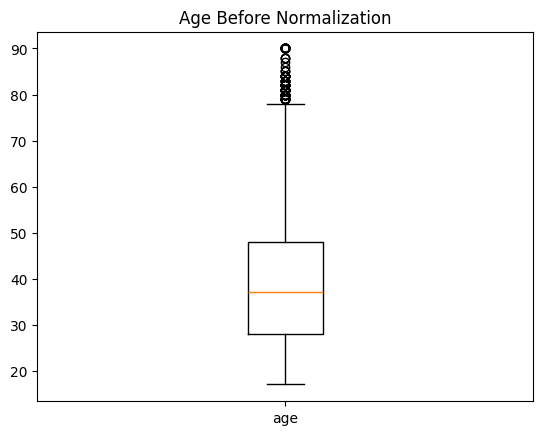

In [40]:
# Vẽ biểu đồ boxplot trước khi chuẩn hóa cho cột "age"
plt.boxplot(train_data_norm["age"], labels=["age"])
plt.title("Age Before Normalization")
plt.show()


### Nhận xét
Biểu đồ cho thấy dữ liệu tập trung chủ yếu trong khoảng từ 27 đến 49 với median gần 40. Phân bố có xu hướng lệch nhẹ, xuất hiện một số outlier ở phía trên với mức độ không lớn. Đối với biến age, cả ba phương pháp chuẩn hoá đều hoạt động ổn định.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\484372447.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_norm["education-num"], labels=["education-num"])


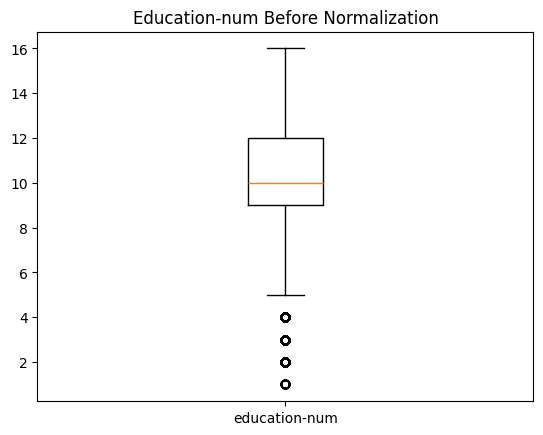

In [41]:
# Vẽ biểu đồ boxplot sau khi chuẩn hóa cho cột "education-num"
plt.boxplot(train_data_norm["education-num"], labels=["education-num"])
plt.title("Education-num Before Normalization")
plt.show()

### Nhận xét
Biểu đồ cho thấy giá trị tập trung chủ yếu khoảng từ 9 đến 13 với median gần 10. Phân bố có xu hướng lệch khá nhẹ, xuất hiện một số outlier ở phía dưới với mức độ thưa. Đối với biến Education-num, cả ba phương pháp chuẩn hoá đều hoạt động ổn định

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\3752524681.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_norm["capital-gain"], labels=["capital-gain"])


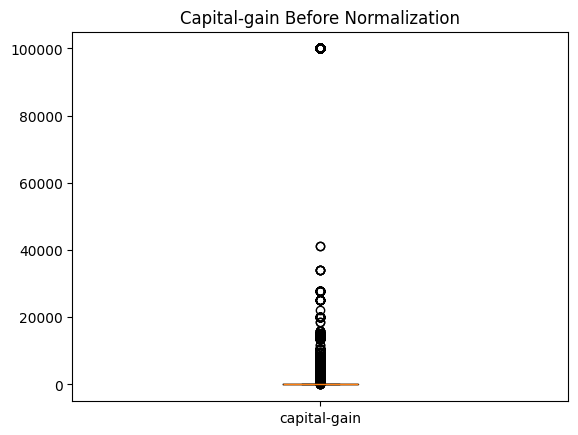

In [42]:
# Vẽ biểu đồ boxplot sau khi chuẩn hóa cho cột "capital-gain"
plt.boxplot(train_data_norm["capital-gain"], labels=["capital-gain"])
plt.title("Capital-gain Before Normalization")
plt.show()

### Nhận xét
Phần lớn giá trị bằng 0, một số ít quan sát có giá trị rất lớn, phân bố lệch phải cực mạnh, xuất hiện rất nhiều giá trị ngoại lai. Các phương pháp chuẩn hoá nhạy với outlier như Min–Max scaling hoặc Z-score normalization có thể không phù hợp, và các phương pháp dựa trên median như Robust scaling có thể sẽ cho kết quả ổn định hơn.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\953794036.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_norm["capital-loss"], labels=["capital-loss"])


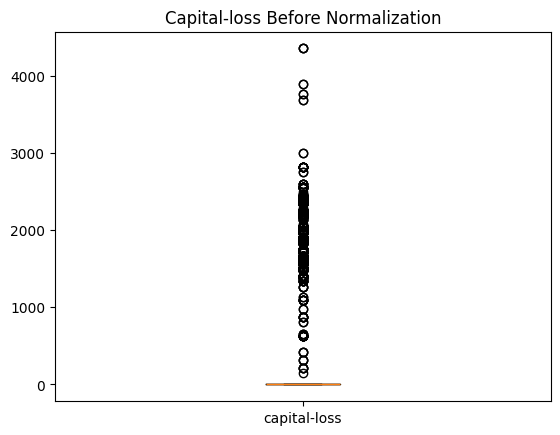

In [43]:
# Vẽ biểu đồ boxplot sau khi chuẩn hóa cho cột "capital-loss"
plt.boxplot(train_data_norm["capital-loss"], labels=["capital-loss"])
plt.title("Capital-loss Before Normalization")
plt.show()

### Nhận xét
Phần lớn giá trị bằng 0, median gần 0, các giá trị dương trải dài lên đến ~4000 xuất hiện rất nhiều, đây là các giá trị outlier kéo trục y lên rất cao, phân bố lệch phải rất mạnh. Điều này cho thấy, mean không đại diện, dữ liệu rất nhạy với outlier. Các phương pháp chuẩn hoá nhạy với outlier như Min–Max scaling hoặc Z-score normalization có thể không phù hợp, và các phương pháp dựa trên median như Robust scaling có thể sẽ cho kết quả ổn định hơn.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\1358288826.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_norm["hours-per-week"], labels=["hours-per-week"])


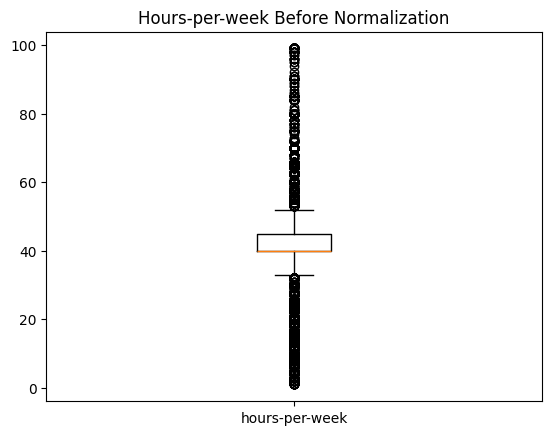

In [44]:
# Vẽ biểu đồ boxplot sau khi chuẩn hóa cho cột "hours-per-week"
plt.boxplot(train_data_norm["hours-per-week"], labels=["hours-per-week"])
plt.title("Hours-per-week Before Normalization")
plt.show()

### Nhận xét
Biểu đồ cho thấy dữ liệu tập trung chủ yếu quanh 40 giờ mỗi tuần, với phân bố tương đối cân đối và chỉ xuất hiện một số ít giá trị ngoại lai ở hai phía. Do đó, các phương pháp chuẩn hoá như Min–Max scaling, Z-score normalization và Robust scaling đều có thể áp dụng mà không gây biến dạng đáng kể.

### Min-Max Scaling

In [45]:
# Chuẩn hóa dữ liệu sử dụng Min-Max Scaling
train_data_minmax = train_data_norm.copy()
train_data_minmax[num_cols] = MinMaxScaler().fit_transform(train_data_norm[num_cols])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\2191338912.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_minmax[num_cols], labels=num_cols)


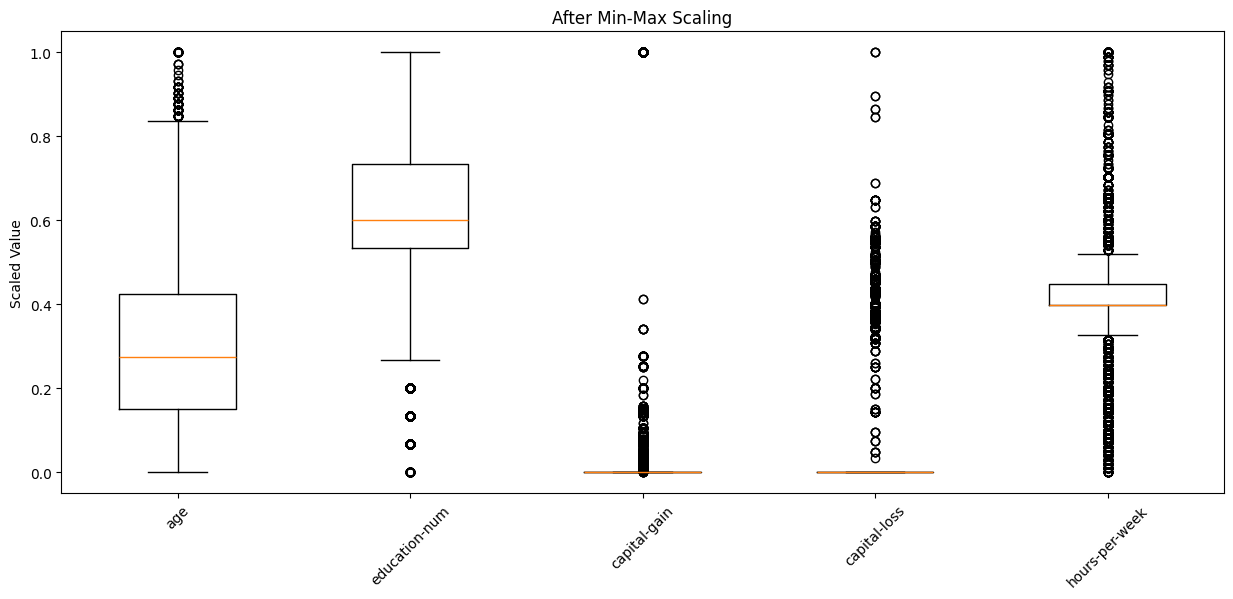

In [46]:
# Vẽ biểu đồ boxplot sau khi chuẩn hóa bằng Min-Max Scaling
plt.figure(figsize=(15,6))
plt.boxplot(train_data_minmax[num_cols], labels=num_cols)
plt.title("After Min-Max Scaling")
plt.ylabel("Scaled Value")
plt.xticks(rotation=45) 
plt.show()


### Z-Score

In [47]:
# Chuẩn hóa dữ liệu sử dụng Standard Scaling
train_data_standard = train_data_norm.copy()
train_data_standard[num_cols] = StandardScaler().fit_transform(train_data_norm[num_cols])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\2750779909.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_standard[num_cols], labels=num_cols)


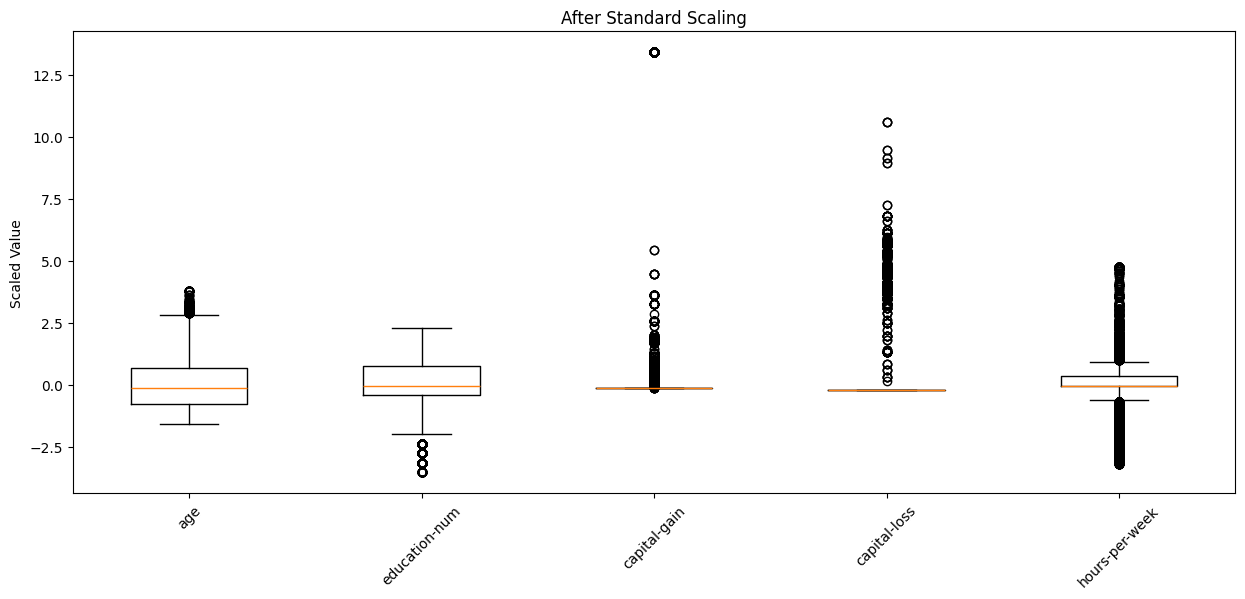

In [48]:
# Vẽ biểu đồ boxplot sau khi chuẩn hóa bằng Z-score Scaling
plt.figure(figsize=(15,6))
plt.boxplot(train_data_standard[num_cols], labels=num_cols)
plt.title("After Standard Scaling")
plt.ylabel("Scaled Value")
plt.xticks(rotation=45) 
plt.show()

### Robust scaling

In [49]:
# Chuẩn hóa dữ liệu sử dụng Robust Scaling
train_data_robust = train_data_norm.copy()
train_data_robust[num_cols] = RobustScaler().fit_transform(train_data_norm[num_cols])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27744\2523876604.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data_robust[num_cols], labels=num_cols)


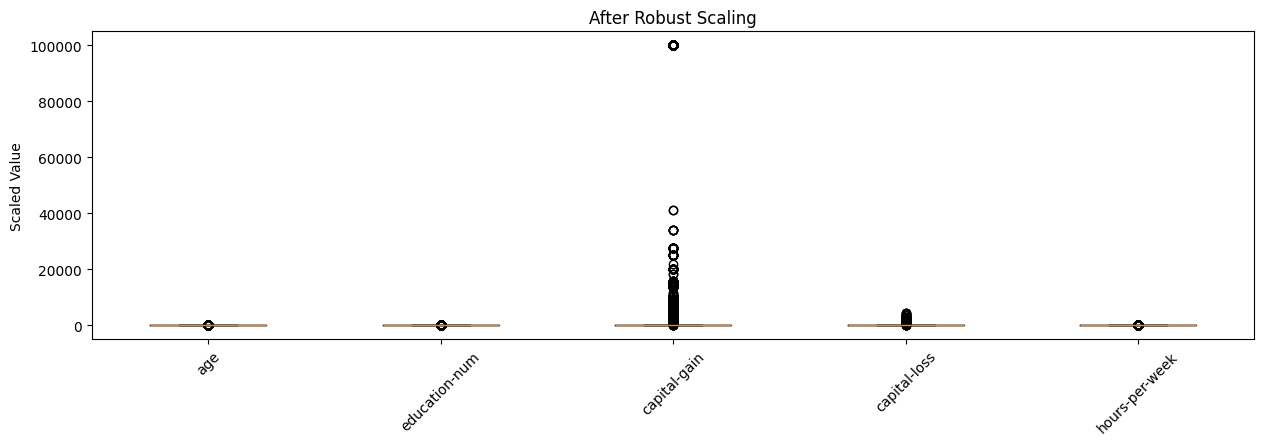

In [50]:
# Vẽ biểu đồ boxplot sau khi chuẩn hóa bằng Robust Scaling
plt.figure(figsize=(15,4))
plt.boxplot(train_data_robust[num_cols], labels=num_cols)
plt.title("After Robust Scaling")
plt.ylabel("Scaled Value")
plt.xticks(rotation=45) 
plt.show()

## Nhận xét 
### Min - Max Scaling
Tất cả biến nằm trong khoảng [0, 1], phân bố vẫn giữ hình dạng gốc.
### Z - Score: 
- Phân bố vẫn giữ hình dạng gốc.
- Trung bình xấp xỉ 0.
- Phần lớn dữ liệu nằm trong khoảng [-2, 2].
- Age, education-num, hours-per-week phân bố khá cân đối.
- Capital-gain và capital-loss có giá trị rất lớn, > 10.
### Robust Scaling:
- Median xấp xỉ 0, đa số các điểm tập trung quanh 0.
- Age, education-num, hour-per-week ít bị kéo lệch, ổn định.
- Outlier vẫn tồn tại ở capital-gain nhưng nhìn chung không làm phá vỡ toàn bộ thang đo.
## So sánh
### Min - Max Scaling:
- Giữ cấu trúc tương đối tốt.
- Bị ảnh hướng mạnh bởi Outlier.
- Các biến lệch mạnh như capital-gain và capital-loss bị ép phẳng, làm mất nhiều thông tin.
- Không phù hợp với dataset hiện tại.
### Z - Score
- Giữ cấu trúc tốt.
- Không loại bỏ được outlier mà còn làm dễ thấy outlier hơn.
- Không phù hợp với capital-gain và capital-loss vì giả định dữ liệu gần phân phối chuẩn, làm xuất hiện các giá trị cực lớn so với các biến còn lại (>10).
- Không phù hợp với dataset hiện tại.
### Robust Scaling
- Giữ cấu trúc dữ liệu tốt, không làm méo dữ liệu trung tâm.
- Ít bị ảnh hưởng bởi outlier, chống outlier tốt nhất trong 3 phương pháp.
- Thang đo có thể không trực quan, giá trị có thể rất lớn.
## Kết luận
Min-Max kém hiệu quả với biến lệch và nhiều outlier. Z - Score kém hiệu quả với outlier lớn, phù hợp với dữ liệu ít lệch hơn. Robust Scaling cho kết quả tốt nhất với dataset hiện tại do dữ liệu chứa nhiều biến có phân phối lệch mạnh và nhiều outlier như capital-gain và capital-loss.


# c) Categorical Encoding
## Xác định biến phân loại cần mã hóa
Vì các biến Nominal không có thứ tự, các biến Ordinal có phân cấp thứ bậc nên ta có thể xác định được dựa trên hiểu biết cá nhân, các biến thuộc 2 loại trên như sau:
- Nominal: workclass, marital-status, occupation, relationship, race, sex, native-country.
- Ordinal: education

In [51]:
nominal_cols = ["workclass", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]
ordinal_cols = ["education"]

### Áp dụng mã hóa phù hợp cho mỗi loại
#### One-hot encoding cho biến Nominal 

In [52]:
onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

#### Ordinal encoding cho biến Ordinal
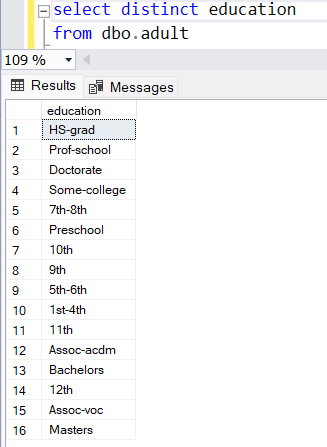

In [53]:
education_order = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]

ordinal_encoder = OrdinalEncoder(categories=[education_order])


Vì OneHotEncoder không biết cột nào cần one-hot, OrdinalEncoder chỉ mã hóa nhãn thành số nên ta cần thêm ColumnTranformer để phân công cột nào cần one-hot, cột nào cần ordinal

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", onehot_encoder, nominal_cols),
        ("ordinal", ordinal_encoder, ordinal_cols)
    ]
)

# Áp dụng biến đổi tiền xử lý lên dữ liệu
processed_data = preprocessor.fit_transform(train_data_norm)

processed_data.shape

(32561, 84)

Kiểm tra tên cột sau encoding

In [58]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['onehot__workclass_Federal-gov', 'onehot__workclass_Local-gov',
       'onehot__workclass_Never-worked', 'onehot__workclass_Private',
       'onehot__workclass_Self-emp-inc',
       'onehot__workclass_Self-emp-not-inc',
       'onehot__workclass_State-gov', 'onehot__workclass_Without-pay',
       'onehot__marital-status_Divorced',
       'onehot__marital-status_Married-AF-spouse',
       'onehot__marital-status_Married-civ-spouse',
       'onehot__marital-status_Married-spouse-absent',
       'onehot__marital-status_Never-married',
       'onehot__marital-status_Separated',
       'onehot__marital-status_Widowed',
       'onehot__occupation_Adm-clerical',
       'onehot__occupation_Armed-Forces',
       'onehot__occupation_Craft-repair',
       'onehot__occupation_Exec-managerial',
       'onehot__occupation_Farming-fishing',
       'onehot__occupation_Handlers-cleaners',
       'onehot__occupation_Machine-op-inspct',
       'onehot__occupation_Other-service',
       'onehot__oc

#### Nhận xét
Chiều tăng lên đến 84 sau khi one-hot. 

Số lượng mẫu không thay đổi, trong khi số lượng thuộc tính tăng lên do mã hóa one-hot.

Tên thuộc tính xác nhận rằng các biến ordinal được mã hóa thành một cột duy nhất, trong khi các biến định danh được mở rộng thành nhiều cột nhị phân.